In [1]:
from pathlib import Path
from scipy.io import loadmat
import scipy.signal as sgn
import pandas as pd
import numpy as np
import re
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, average_precision_score


In [2]:
from Functions import remove_baseline_filter,  preprocess_one_file , stem_to_subject_id , prepare_split_data_loaders,training_curve_plot , WindowDataset, CNN1D, train_model_with_loaders, eval_loader_binary , run_one_experiment , select_channels

## Preprocessing step

In [3]:

folder = Path(r"C:\Users\saber\thesis_second_try\data\Rest\Respiration_ECG_Raw")


# Parameters
FS_IN = 1000
FS_OUT = 60
WIN_LEN = 2048
STRIDE = WIN_LEN  # non-overlap
batch_size = 64

SIGNAL_ORDER = ["ECG_mV", "Fingerpulse", "Cannula", "Thermopod"]

SCALE = {
    "ECG_mV": 1000.0,      # V -> mV
    "Fingerpulse": 10.0,
    "Cannula": 10.0,
    "Thermopod": 1.0
}

# ────────────────────────────────────────────────
# The baseline function 
SOS = remove_baseline_filter(FS_IN)

#────────────────────────────────────────────────
# Run over alla the files
mat_files = sorted(folder.glob("*.mat"))
participant_files = [f for f in mat_files if f.name.startswith("resting_state_participant_")]
print("Total .mat files:", len(mat_files))
print("Participant files:", len(participant_files))

#────────────────────────────────────────────────
# Split the files in mouth and nose 
nose_files, mouth_files, skipped = [], [], []
for f in participant_files:
    m = re.search(r"participant_(\d+)", f.stem)
    if not m:
        skipped.append(f.name)
        continue
    pid = int(m.group(1))
    if 10 <= pid <= 112:
        nose_files.append(f)
    elif 200 <= pid <= 312:
        mouth_files.append(f)
    else:
        skipped.append(f.name)

print("Nose files :", len(nose_files))
print("Mouth files:", len(mouth_files))
print("Skipped    :", len(skipped))

#────────────────────────────────────────────────
# Preprocess each group 
nose_tensors_by_participant = {}
mouth_tensors_by_participant = {}
failed = []
# 1. for nose 
for f in nose_files:
    try:
        nose_tensors_by_participant[f.stem] = preprocess_one_file(
            f,
            fs_in=FS_IN,
            fs_out=FS_OUT,
            win_len=WIN_LEN,
            stride=STRIDE,
            keep_signals=SIGNAL_ORDER,
            scale=SCALE,
            sos=SOS,
        )
    except Exception as e:
        failed.append((f.name, "nose", str(e)))
# 2. for mouth
for f in mouth_files:
    try:
        mouth_tensors_by_participant[f.stem] = preprocess_one_file(
            f,
            fs_in=FS_IN,
            fs_out=FS_OUT,
            win_len=WIN_LEN,
            stride=STRIDE,
            keep_signals=SIGNAL_ORDER,
            scale=SCALE,
            sos=SOS,
        )
    except Exception as e:
        failed.append((f.name, "mouth", str(e)))

print("Processed nose :", len(nose_tensors_by_participant))
print("Processed mouth:", len(mouth_tensors_by_participant))
print("Failed:", len(failed))

#────────────────────────────────────────────────
# Stacking the tensors 
if len(nose_tensors_by_participant) > 0:
    nose_keys = sorted(nose_tensors_by_participant.keys())
    X_nose = np.stack([nose_tensors_by_participant[k] for k in nose_keys], axis=0)
    print("X_nose shape:", X_nose.shape)  # (P_nose, n_windows, 2, 2048)

if len(mouth_tensors_by_participant) > 0:
    mouth_keys = sorted(mouth_tensors_by_participant.keys())
    X_mouth = np.stack([mouth_tensors_by_participant[k] for k in mouth_keys], axis=0)
    print("X_mouth shape:", X_mouth.shape)  # (P_mouth, n_windows, 2, 2048)


Total .mat files: 207
Participant files: 205
Nose files : 102
Mouth files: 103
Skipped    : 0
Processed nose : 102
Processed mouth: 103
Failed: 0
X_nose shape: (102, 9, 4, 2048)
X_mouth shape: (103, 9, 4, 2048)


In [4]:
# Checking that everything is working
nose_keys = sorted(nose_tensors_by_participant.keys()) 
# print(nose_keys)
print("X_nose shape:", X_nose .shape)
X_nose = np.stack([nose_tensors_by_participant[k] for k in nose_keys], axis=0)
print("First 5 keys:", nose_keys[:5])

X_nose shape: (102, 9, 4, 2048)
First 5 keys: ['resting_state_participant_010', 'resting_state_participant_011', 'resting_state_participant_012', 'resting_state_participant_013', 'resting_state_participant_014']


## Dataframe for the mouth 
The df was previously save cleaned and saved locally 

In [5]:
import pandas as pd
Path_subject = r"df_nose.csv"
df_nose= pd.read_csv(Path_subject)
df_nose.head()

,Subject Number,Gender,Age
0,10,1,37
1,11,1,29
2,12,0,25
3,13,0,31
4,14,0,28


In [6]:
gender_by_subject = dict(zip(df_nose["Subject Number"], df_nose["Gender"]))
gender_by_subject # this is subject id and their correct gender 


{10: 1,
 11: 1,
 12: 0,
 13: 0,
 14: 0,
 15: 0,
 16: 0,
 17: 0,
 18: 0,
 19: 0,
 20: 1,
 21: 0,
 22: 0,
 23: 0,
 24: 0,
 25: 0,
 26: 0,
 27: 0,
 28: 1,
 29: 1,
 30: 1,
 31: 0,
 33: 0,
 34: 0,
 35: 0,
 36: 0,
 37: 1,
 38: 0,
 39: 1,
 40: 0,
 41: 0,
 42: 0,
 43: 0,
 44: 0,
 45: 0,
 46: 0,
 47: 0,
 48: 1,
 49: 0,
 50: 1,
 51: 0,
 52: 0,
 53: 1,
 54: 1,
 55: 0,
 56: 0,
 57: 1,
 58: 0,
 59: 1,
 60: 0,
 61: 0,
 62: 0,
 63: 0,
 64: 1,
 65: 0,
 66: 0,
 67: 1,
 68: 1,
 69: 1,
 70: 1,
 71: 0,
 72: 0,
 73: 1,
 74: 0,
 75: 0,
 76: 0,
 77: 1,
 78: 0,
 79: 0,
 80: 0,
 81: 0,
 82: 0,
 83: 0,
 84: 0,
 85: 1,
 86: 1,
 87: 1,
 88: 0,
 89: 0,
 90: 0,
 91: 1,
 92: 0,
 93: 1,
 94: 0,
 95: 1,
 96: 0,
 97: 1,
 98: 1,
 99: 1,
 100: 1,
 101: 1,
 102: 0,
 103: 1,
 104: 0,
 105: 1,
 106: 0,
 107: 0,
 108: 1,
 109: 1,
 110: 0,
 111: 0,
 112: 1}

In [7]:
nose_ids_from_files = np.array([stem_to_subject_id(k) for k in nose_keys], dtype=int)

print("First 10 subject IDs from files:", nose_ids_from_files[:10])
print("Number of participants from files:", len(nose_ids_from_files))
print("Unique IDs:", len(np.unique(nose_ids_from_files)))


# mouth_ids_for_labels = mouth_ids_from_files - 200

print("First 10 raw mouth IDs:   ", nose_ids_from_files[:10])
# print("First 10 mapped label IDs:", mouth_ids_for_labels[:10])

y_nose = np.array([gender_by_subject[sid] for sid in nose_ids_from_files], dtype=int)
print("y_nose gender:", y_nose)
print("y_nose shape:", y_nose.shape)
print("Gender counts [0,1]:", np.bincount(y_nose))


First 10 subject IDs from files: [10 11 12 13 14 15 16 17 18 19]
Number of participants from files: 102
Unique IDs: 102
First 10 raw mouth IDs:    [10 11 12 13 14 15 16 17 18 19]
y_nose gender: [1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0
 1 0 1 0 0 1 1 0 0 1 0 1 0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0
 1 1 1 0 0 0 1 0 1 0 1 0 1 1 1 1 1 0 1 0 1 0 0 1 1 0 0 1]
y_nose shape: (102,)
Gender counts [0,1]: [65 37]


# The split 

In [8]:


train_loader, val_loader, test_loader, meta = prepare_split_data_loaders(
    X_nose, y_nose,
    seed=6,
    batch_size=batch_size,
    normalize=True,
    return_meta=True
)

# baseline: majority-class accuracy on validation participants
X_val_p = meta["X_val_p"]
y_val_p = meta["y_val_p"]
baseline_acc = max(np.mean(y_val_p == 0), np.mean(y_val_p == 1))
# ────────────────────────────────────────────────
#  Quick sanity checks on test set 

print("\nFirst 20 test window labels:", meta['y_test'][10:40])

print("Example test window [0] – channel means:", meta['X_test'][0].mean(axis=1))

# If you want to see beginning of first channel of first test window:
print("Example test window[0] channel 0 – first 30 values:")
print(meta['X_test'][0, 0, :30])

X_mouth:     (102, 9, 4, 2048)
y_mouth:     (102,)   unique: [0 1]   counts: [65 37]

After normalization (train mean per ch): [-2.6680533e-09  4.5378734e-10  2.7411160e-09  7.5750801e-09]
After normalization (train std  per ch): [0.99999964 0.9999998  0.9999999  0.99999964]

Window-level shapes:
X_train:     (576, 4, 2048)  y_train: (576,)  counts: [369 207]
X_val  :     (153, 4, 2048)  y_val  : (153,)  counts: [99 54]
X_test :     (189, 4, 2048)  y_test : (189,)  counts: [117  72]

First 20 test window labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0]
Example test window [0] – channel means: [ 0.00201165 -0.00027668 -0.00085785 -0.0002708 ]
Example test window[0] channel 0 – first 30 values:
[-0.15468664 -0.20944187  0.0113573  -0.00712441 -0.01802046 -0.26778373
 -0.36157084 -0.35898265 -0.19587593 -0.02024161  4.2535367   1.7092631
 -1.284979    0.24923901 -0.17638147  0.13319993  0.03211309  0.2691964
  0.24082163  0.3723247   0.5234933   0.72161585  1.107011  

## Training step 

Epoch 01 | train loss 0.8437 acc 0.628 | val loss 0.8729 acc 0.353
Epoch 02 | train loss 0.8175 acc 0.668 | val loss 0.8538 acc 0.536
Epoch 03 | train loss 0.7926 acc 0.720 | val loss 0.8368 acc 0.634
Epoch 04 | train loss 0.7842 acc 0.714 | val loss 0.8262 acc 0.627
Epoch 05 | train loss 0.7600 acc 0.738 | val loss 0.8210 acc 0.627
Epoch 06 | train loss 0.7590 acc 0.726 | val loss 0.8175 acc 0.614
Epoch 07 | train loss 0.7423 acc 0.724 | val loss 0.8171 acc 0.634
Epoch 08 | train loss 0.7425 acc 0.731 | val loss 0.8160 acc 0.634
Epoch 09 | train loss 0.7319 acc 0.736 | val loss 0.8179 acc 0.634
Epoch 10 | train loss 0.7212 acc 0.745 | val loss 0.8193 acc 0.634
Epoch 11 | train loss 0.7077 acc 0.753 | val loss 0.8226 acc 0.627
Epoch 12 | train loss 0.7101 acc 0.752 | val loss 0.8245 acc 0.627
Epoch 13 | train loss 0.7062 acc 0.741 | val loss 0.8189 acc 0.627
Epoch 14 | train loss 0.7028 acc 0.767 | val loss 0.8202 acc 0.614
Epoch 15 | train loss 0.6858 acc 0.755 | val loss 0.8225 acc 0

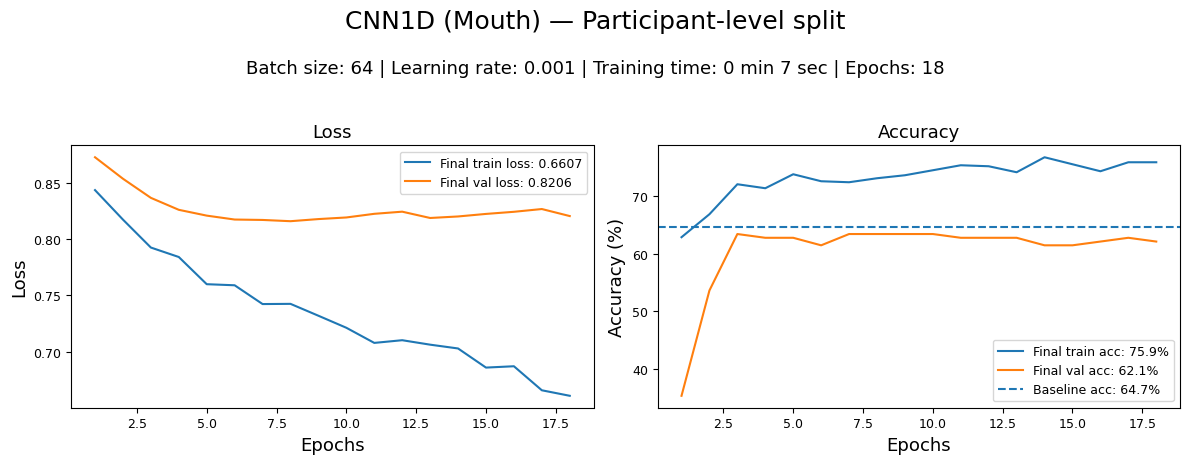

In [9]:
Epochs = 50 
lr = 1e-3
patience=10 

model = CNN1D(len(SIGNAL_ORDER))


t0 = time.time()
model, trL, vaL, trA, vaA, trP, valP, _= train_model_with_loaders(
    model,
    train_loader,
    val_loader,
    epochs=Epochs,
    lr=lr,
    patience=patience,
    use_pos_weight=True
)
t1 = time.time()


print("Final train acc:", trA[-1])
print("Final val acc:", vaA[-1])

training_curve_plot(
    title="CNN1D (Mouth) — Participant-level split",
    train_losses=trL,
    val_losses=vaL,
    train_accs=trA,
    val_accs=vaA,
    batch_size=64,
    learning_rate=0.001,
    training_time=(t1 - t0),
    baseline_acc=baseline_acc
)

## The evalutaion section

In [10]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score

def eval_loader_binary(model, loader, device=None, threshold=0.5, verbose=True, name="LOADER"):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)
    model.eval()

    y_prob_list, y_true_list, y_pred_list = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)

            logits = model(xb).view(-1)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            preds = (probs >= threshold).astype(int)

            y_prob_list.append(probs)
            y_pred_list.append(preds)
            y_true_list.append(yb.detach().cpu().numpy().astype(int).reshape(-1))

    y_true = np.concatenate(y_true_list) if y_true_list else np.array([], dtype=int)
    y_pred = np.concatenate(y_pred_list) if y_pred_list else np.array([], dtype=int)
    y_prob = np.concatenate(y_prob_list) if y_prob_list else np.array([], dtype=float)

    acc = accuracy_score(y_true, y_pred) if len(y_true) else float("nan")

    if verbose:
        print(f"{name} accuracy (window-level): {acc:.4f}")

    return y_true, y_pred, y_prob, acc


In [11]:
print(eval_loader_binary)


<function eval_loader_binary at 0x00000284EB429870>


In [12]:
y_tr, yhat_tr, p_tr, acc_tr = eval_loader_binary(model, train_loader, name="TRAIN")
y_va, yhat_va, p_va, acc_va = eval_loader_binary(model, val_loader,   name="VAL")
y_te, yhat_te, p_te, acc_te = eval_loader_binary(model, test_loader,  name="TEST")


TRAIN accuracy (window-level): 0.7500
VAL accuracy (window-level): 0.6340
TEST accuracy (window-level): 0.6243


In [13]:
# for the test


print(f"Accuracy:           {accuracy_score(y_te, yhat_te):.4f}")
print(f"Balanced acc:       {balanced_accuracy_score(y_te, yhat_te):.4f}")
print(f"F1 (positive):      {f1_score(y_te, yhat_te):.4f}")
print(f"ROC AUC:            {roc_auc_score(y_te, p_te):.4f}")
print(f"Average Precision:  {average_precision_score(y_te, p_te):.4f}")

print("\nCM:\n", confusion_matrix(y_te, yhat_te))
print(classification_report(y_te, yhat_te, digits=4))


Accuracy:           0.6243
Balanced acc:       0.6084
F1 (positive):      0.5235
ROC AUC:            0.6550
Average Precision:  0.5264

CM:
 [[79 38]
 [33 39]]
              precision    recall  f1-score   support

           0     0.7054    0.6752    0.6900       117
           1     0.5065    0.5417    0.5235        72

    accuracy                         0.6243       189
   macro avg     0.6059    0.6084    0.6067       189
weighted avg     0.6296    0.6243    0.6265       189



In [14]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Put your data in a list of tuples
datasets = [
    ("TRAIN", y_tr,  yhat_tr,  p_tr),
    ("VAL",   y_va,  yhat_va,  p_va),
    ("TEST",  y_te,  yhat_te,  p_te),
]

for name, y_true, y_pred, y_prob in datasets:
    print(f"\n ----- {name}----")
    
    acc     = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1      = f1_score(y_true, y_pred)
    auc     = roc_auc_score(y_true, y_prob)
    ap      = average_precision_score(y_true, y_prob)
    
    print(f"Accuracy:              {acc:.4f}")
    print(f"Balanced accuracy:     {bal_acc:.4f}")
    print(f"F1 (positive class):   {f1:.4f}")
    print(f"ROC AUC:               {auc:.4f}")
    print(f"Average Precision:     {ap:.4f}")
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    
    print("━" * 50)


 ----- TRAIN----
Accuracy:              0.7500
Balanced accuracy:     0.7402
F1 (positive class):   0.6697
ROC AUC:               0.8251
Average Precision:     0.7063

Confusion Matrix:
[[286  83]
 [ 61 146]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8242    0.7751    0.7989       369
           1     0.6376    0.7053    0.6697       207

    accuracy                         0.7500       576
   macro avg     0.7309    0.7402    0.7343       576
weighted avg     0.7571    0.7500    0.7525       576

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 ----- VAL----
Accuracy:              0.6340
Balanced accuracy:     0.6035
F1 (positive class):   0.4909
ROC AUC:               0.7011
Average Precision:     0.6015

Confusion Matrix:
[[70 29]
 [27 27]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7216    0.7071    0.7143        99
           1     0.4821    0.5000    0.4909        

In [15]:


# print(f"Accuracy:           {accuracy_score(y_true, y_pred):.4f}")
# print(f"Balanced acc:       {balanced_accuracy_score(y_true, y_pred):.4f}")
# print(f"F1 (positive):      {f1_score(y_true, y_pred):.4f}")
# print(f"ROC AUC:            {roc_auc_score(y_true, y_prop):.4f}")
# print(f"Average Precision:  {average_precision_score(y_true, y_prop):.4f}")
# print("\nCM:\n", confusion_matrix(y_true, y_pred))
# print(classification_report(y_true, y_pred, digits=4))

In [16]:


FULL_SIGNAL_ORDER = ["ECG_mV", "Fingerpulse", "Cannula", "Thermopod"]

signal_sets = [
    ["ECG_mV"],
    ["Fingerpulse"],
    ["Cannula"],                          # 1 signal
    ["Thermopod"],                        # 1 signal
    #["Cannula", "Thermopod"],             # 2 signals
    ["ECG_mV", "Fingerpulse"],            # 2 signals
    ["ECG_mV", "Cannula"],            # 2 signals
    ["ECG_mV", "Thermopod"],            # 2 signals
    ["ECG_mV", "Fingerpulse","Thermopod"],   # 3 signals
    ["ECG_mV", "Fingerpulse", "Cannula"],   # 3 signals
    FULL_SIGNAL_ORDER,                    # 4 signals
]

seeds = [1, 2, 3, 4, 5]


In [20]:
results = []
for keep in signal_sets:
    for seed in seeds:
        m = run_one_experiment(
            X_full=X_nose,
            y=y_nose,
            full_order=FULL_SIGNAL_ORDER,
            keep_signals=keep,
            seed=seed,
            Epochs=50,
            lr=1e-3,
            patience=10,
            batch_size=64,
        )
        print(f"done: seed={seed}, signals={keep} -> acc={m['test_acc']:.3f}, auc={m['test_roc_auc']:.3f}")
        results.append(m)


Epoch 01 | train loss 0.8921 acc 0.608 | val loss 0.8864 acc 0.333
Epoch 02 | train loss 0.8841 acc 0.583 | val loss 0.8833 acc 0.340
Epoch 03 | train loss 0.8745 acc 0.571 | val loss 0.8794 acc 0.412
Epoch 04 | train loss 0.8561 acc 0.604 | val loss 0.8803 acc 0.490
Epoch 05 | train loss 0.8481 acc 0.625 | val loss 0.8880 acc 0.601
Epoch 06 | train loss 0.8513 acc 0.620 | val loss 0.8912 acc 0.556
Epoch 07 | train loss 0.8252 acc 0.668 | val loss 0.8941 acc 0.484
Epoch 08 | train loss 0.8219 acc 0.663 | val loss 0.9002 acc 0.556
Epoch 09 | train loss 0.8222 acc 0.667 | val loss 0.9100 acc 0.601
Epoch 10 | train loss 0.8223 acc 0.634 | val loss 0.9028 acc 0.412
Epoch 11 | train loss 0.8069 acc 0.679 | val loss 0.9038 acc 0.458
Epoch 12 | train loss 0.8183 acc 0.655 | val loss 0.9098 acc 0.490
Epoch 13 | train loss 0.8089 acc 0.658 | val loss 0.9145 acc 0.516
Early stopping at epoch 13
TEST accuracy (window-level): 0.6296
done: seed=1, signals=['ECG_mV'] -> acc=0.630, auc=0.655
Epoch 01

In [26]:
df = pd.DataFrame(results)
df.to_csv("df_nose_different_Signals.csv", index=False)
print(df.shape)
df.head(50)


(50, 10)


,seed,keep_signals,n_signals,test_acc,test_bal_acc,test_f1,test_roc_auc,test_avg_precision,final_train_acc,final_val_acc
0,1,"(ECG_mV,)",1,0.629630,0.668803,0.631579,0.654796,0.532149,0.657986,0.516340
1,2,"(ECG_mV,)",1,0.380952,0.500000,0.551724,0.614079,0.624332,0.642361,0.366013
2,3,"(ECG_mV,)",1,0.380952,0.500000,0.551724,0.579891,0.519109,0.605903,0.529412
3,4,"(ECG_mV,)",1,0.708995,0.690171,0.615385,0.757360,0.689202,0.640625,0.431373
4,5,"(ECG_mV,)",1,0.518519,0.520299,0.455090,0.619539,0.604588,0.770833,0.758170
5,1,"(Fingerpulse,)",1,0.550265,0.545940,0.472050,0.452160,0.352651,0.689236,0.686275
6,2,"(Fingerpulse,)",1,0.587302,0.565171,0.465753,0.556980,0.429824,0.673611,0.699346
7,3,"(Fingerpulse,)",1,0.523810,0.500534,0.391892,0.510565,0.382402,0.642361,0.692810
8,4,"(Fingerpulse,)",1,0.507937,0.442308,0.205128,0.435660,0.408238,0.680556,0.633987
9,5,"(Fingerpulse,)",1,0.703704,0.664530,0.562500,0.654084,0.628077,0.605903,0.843137


In [27]:
import numpy as np

summary = df.groupby("keep_signals")["test_roc_auc"].agg(
    median=np.median,
    p25=lambda x: np.percentile(x, 25),
    p75=lambda x: np.percentile(x, 75),
).reset_index()

summary


,keep_signals,median,p25,p75
0,"(Cannula,)",0.728989,0.712963,0.747270
1,"(ECG_mV,)",0.619539,0.614079,0.654796
2,"(ECG_mV, Cannula)",0.751306,0.750119,0.777778
3,"(ECG_mV, Fingerpulse)",0.695869,0.669634,0.714744
4,"(ECG_mV, Fingerpulse, Cannula)",0.728276,0.702398,0.782051
5,"(ECG_mV, Fingerpulse, Cannula, Thermopod)",0.734212,0.697293,0.741216
6,"(ECG_mV, Fingerpulse, Thermopod)",0.643519,0.616216,0.668329
7,"(ECG_mV, Thermopod)",0.584520,0.545228,0.669753
8,"(Fingerpulse,)",0.510565,0.452160,0.556980
9,"(Thermopod,)",0.587251,0.584164,0.762227


<Figure size 1400x600 with 0 Axes>

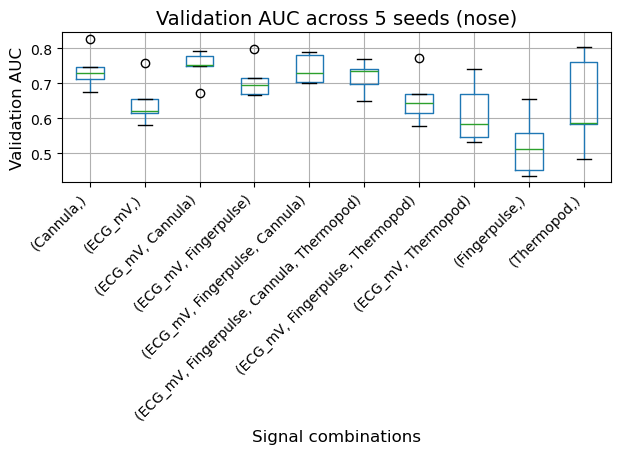

In [28]:
import matplotlib.pyplot as plt



plt.figure(figsize=(14,6))  
df.boxplot(column="test_roc_auc", by="keep_signals")
plt.title("Validation AUC across 5 seeds (nose)", fontsize=14)
plt.suptitle("")
plt.ylabel("Validation AUC", fontsize=12)
plt.xlabel("Signal combinations", fontsize=12)

plt.xticks(rotation=45, ha="right")   # better label alignment
plt.tight_layout()
plt.show()
